# Análisis Exploratorio del archivo de datos de Diagnóstico y Comorbilidades 

**Contexto:** `INER_COVID19_Pacientes_DiagnosticoComorbilidad.csv` contiene información clínica: diagnósticos principales, códigos CIE-10, comorbilidades y datos de ingreso/egreso de pacientes COVID-19 del INER. Se vinculará con `CostoPacientes_Econo` y `TrabajoSocial` mediante un sistema de Ligado de Registros (Record Linkage) que serializa cada registro tabular en una cadena de texto mapeando cada columna en bloques semánticos (`[BLK_ID]`, `[BLK_CLIN]`, `[BLK_GEO]`, `[BLK_SOCIO]`, `[BLK_ADMIN]`) con un límite de **256 tokens** por registro.

El notebook debe proporcionar información clave para generar productos necesarios en los objetivos del proyecto de consultoría y de tesis. Esto incluye:
* Diccionario detallado de los datos crudos y eventualmente uno final para la base de datos consolidada
* Identificar problemas de calidad que podrían afectar la serialización o desarrollos posteriores
* Mapeo de las columnas a los bloques semánticos definidos, estimando la cantidad de los tokens sujetos al al presupuesto.


## 0. Carga de datos y configuración

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path
import re
from collections import Counter
import unicodedata
import sys
from pathlib import Path

sys.path.insert(0, str(Path('..').resolve() / 'src'))
from record_linkage.config import RAW_FILES, check_paths, FIGURES_DIR

# Configuración de estilos para gráficos
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.05)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.figsize'] = (12, 5)

df = pd.read_csv(RAW_FILES['comorbilidad'])

# Conversión inmediata de fechas (no válidas en NaT)
for col_f in ['fechaing', 'fechaegr']:
    df[col_f] = pd.to_datetime(df[col_f], errors='coerce')

## 1. Caracterización de Columnas

### 1.1 Panorama general del csv — Tipos de datos, nulos y cardinalidad

In [5]:
resumen = pd.DataFrame({
    'Tipo de Dato Detectado': df.dtypes,
    'No Nulos': df.count(),
    'Nulos': df.isnull().sum(),
    '% Nulos': (df.isnull().sum() / len(df) * 100).round(2),
    'Únicos': df.nunique(),
})
display(resumen.style
        .format({'% Nulos': '{:.2f}%'})
        .background_gradient(subset=['% Nulos'], cmap='OrRd')
        .set_caption(f'Resumen | {df.shape[0]:,} registros y {df.shape[1]} columnas')
        .set_table_styles([{'selector': 'caption', 'props': 'font-size:1.2em; font-weight:bold'}]))

,Tipo de Dato Detectado,No Nulos,Nulos,% Nulos,Únicos
expediente,int64,4278,0,0.00%,4097
nombre,str,4278,0,0.00%,4150
fechaing,datetime64[us],4278,0,0.00%,988
fechaegr,datetime64[us],4278,0,0.00%,982
diagnosticoprincipal,str,4278,0,0.00%,214
cie101,str,4278,0,0.00%,3
diagnostico2,str,2927,1351,31.58%,204
cie102,str,2915,1363,31.86%,114
diagnostico3,str,1563,2715,63.46%,83
cie103,str,1561,2717,63.51%,59


### 1.2 Mapa de calor de valores nulos

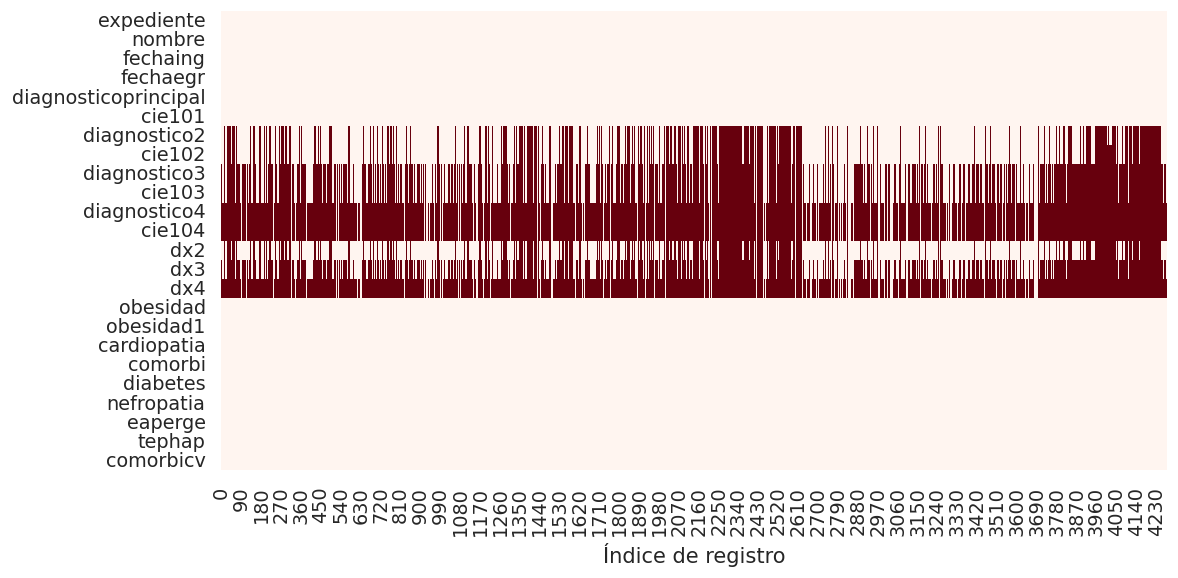

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(df.isnull().T, cbar=False, cmap='Reds', yticklabels=True, ax=ax)
ax.set_xlabel('Índice de registro')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'heatmap_nulos_comorbilidad.png', dpi=150)
plt.show()

### 1.3 Análisis detallado por tipo de variable

En esta sección, para cada una de las 24 columnas, identificamos su tipo de variable y confirmamos qué información contiene realmente, de acuerdo con las siguientes subsecciones de análisis:

- **1.3.1 Identificadores y fechas (4 columnas):**
  - `expediente`, `nombre`, `fechaing`, `fechaegr`

- **1.3.2 Variables categóricas: Diagnósticos, Texto clínico y códigos CIE-10 (11 columnas):**
  - `diagnosticoprincipal`, `diagnostico2`, `diagnostico3`, `diagnostico4`
  - `cie101`, `cie102`, `cie103`, `cie104`
  - `dx2`, `dx3`, `dx4`

- **1.3.3 Variables categóricas: Comorbilidades agrupadas (2 columnas):**
  - `comorbi`, `comorbicv`

- **1.3.4 Variables binarias: Comorbilidades específicas (7 columnas):**
  - `obesidad`, `obesidad1`, `cardiopatia`, `diabetes`, `nefropatia`, `eaperge`, `tephap`


Esto cubre las 24 columnas del csv.

#### 1.3.1 Identificadores y fechas

In [ ]:
# Top 10 valores más frecuentes en EXP
top_exp = df['expediente'].value_counts().head(10).reset_index()
top_exp.columns = ['expediente', 'Frecuencia']

display(top_exp.style
        .set_caption('Top 10 valores más frecuentes en `expediente`')
        .set_table_styles([{'selector': 'caption', 'props': 'font-size:1.1em; font-weight:bold'}])
        .hide(axis='index'))

# --- NOMBRE_DEL_PACIENTE: estructura de tokens ---
nombres = df['nombre'].dropna()

# Top 10 nombres más frecuentes
top_nombres = nombres.value_counts().head(10).reset_index()
top_nombres.columns = ['nombre', 'Frecuencia']

display(top_nombres.style
        .set_caption('Top 10 nombres más frecuentes en `nombre`')
        .set_table_styles([{'selector': 'caption', 'props': 'font-size:1.1em; font-weight:bold'}])
        .hide(axis='index'))

# --- FECHAS: rango y distribución ---
cols_fecha = ['fechaing', 'fechaegr']
rows_fecha = []
for col in cols_fecha:
    serie = df[col].dropna()
    rows_fecha.append({
        'Campo': col,
        'Nulos': int(df[col].isna().sum()),
        'Fecha mín': serie.min().strftime('%Y-%m-%d') if len(serie) else '',
        'Fecha máx': serie.max().strftime('%Y-%m-%d') if len(serie) else '',
        'Años cubiertos': sorted(serie.dt.year.unique().tolist()),
    })

display(pd.DataFrame(rows_fecha).style
        .set_caption('Campos de fecha: rango temporal')
        .set_table_styles([{'selector': 'caption', 'props': 'font-size:1.1em; font-weight:bold'}])
        .hide(axis='index'))


expediente,Frecuencia
249200,5
238376,4
238904,4
242473,4
191202,3
232632,3
237871,3
114639,3
238389,3
238743,3


nombre,Frecuencia
VICENTE MARTIN VALENCIA CHAVEZ,5
JAVIER RODRIGUEZ ROJAS,4
ALBERTO GARCIA RAMIREZ,4
GABINO LEMUS HERNANDEZ,3
RUBEN SECUNDINO AGAPITO,3
CRECENCIO HERNANDEZ LOPEZ,3
GONZALO BECERRIL GUTIERREZ,3
JORGE ARTURO VELAZQUEZ CARRANZA,3
FELIPE GONZALEZ GUTIERREZ,2
DAVID RAMOS DIMAS,2


Campo,Nulos,Fecha mín,Fecha máx,Años cubiertos
fechaing,0,2020-02-28,2023-12-19,"[2020, 2021, 2022, 2023]"
fechaegr,0,2020-03-02,2023-12-24,"[2020, 2021, 2022, 2023]"


#### 1.3.2 Variables categóricas: Diagnósticos, Texto clínico y códigos CIE-10

In [38]:
cols_cat = ['diagnosticoprincipal', 'diagnostico2', 'diagnostico3', 'diagnostico4', 'cie101', 'cie102', 'dx2', 'cie103', 'dx3', 'cie104', 'dx4']

for col in cols_cat:
    vc = df[col].value_counts(dropna=False)
    df_vc = vc.reset_index()
    df_vc.columns = [col, 'Registros']
    df_vc['%'] = (df_vc['Registros'] / len(df) * 100).round(1)
    df_vc[col] = df_vc[col].fillna('⟨NaN⟩')

    # Para campos con muchas categorías, mostrar solo top 10
    if len(df_vc) > 10:
        otros = df_vc.iloc[10:]
        fila_otros = pd.DataFrame([{col: f'… ({len(otros)} más)', 'Registros': otros['Registros'].sum(),
                                     '%': otros['%'].sum().round(1)}])
        df_vc = pd.concat([df_vc.head(10), fila_otros], ignore_index=True)
    display(df_vc.style
            .format({'%': '{:.1f}%'}, na_rep='—')
            .set_caption(f"{col}  ({df[col].nunique()} categorías, {df[col].isna().sum()} nulos)")
            .bar(subset=['Registros'], color="#1428a7")
            .set_table_styles([{'selector': 'caption', 'props': 'font-size:1.1em; font-weight:bold'}])
            .hide(axis='index'))


diagnosticoprincipal,Registros,%
NEUMONIA POR SARS COV2,1428,33.4%
SARS-COV2,490,11.5%
COVID 19,264,6.2%
NEUMONIA POR COVID 19,254,5.9%
ENFERMEDAD RESPIRATORIA AGUDA POR nCOV,150,3.5%
INFECCION POR SARS COV2,140,3.3%
NEUMONIA VIRAL POR COVID 19,125,2.9%
NEUMONIA VIRAL POR SARS COV2,101,2.4%
ENFERMEDAD RESPIRATORIA AGUDA POR nCOV,94,2.2%
COVID 19,91,2.1%


diagnostico2,Registros,%
⟨NaN⟩,1351,31.6%
SINDROME DE INSUFICIENCIA RESPIRATORIA AGUDA,1116,26.1%
HAS,348,8.1%
INSUFICIENCIA RESPIRATORIA TIPO I,216,5.0%
INSUFICIENCIA RESPIRATORIA AGUDA,169,4.0%
DIABETES MELLITUS TIPO II,129,3.0%
OBESIDAD GRADO I,82,1.9%
CHOQUE SEPTICO,77,1.8%
SOBREPESO,64,1.5%
ESTENOSIS TRAQUEAL,48,1.1%


diagnostico3,Registros,%
⟨NaN⟩,2715,63.5%
HAS,432,10.1%
DIABETES MELLITUS TIPO II,356,8.3%
CHOQUE SEPTICO,185,4.3%
OBESIDAD GRADO I,119,2.8%
SOBREPESO,115,2.7%
OBESIDAD GRADO II,52,1.2%
SINDROME DE INSUFICIENCIA RESPIRATORIA AGUDA,36,0.8%
INSUFICIENCIA RESPIRATORIA TIPO I,22,0.5%
OBESIDAD,22,0.5%


diagnostico4,Registros,%
⟨NaN⟩,3817,89.2%
DIABETES MELLITUS TIPO II,207,4.8%
CHOQUE SEPTICO,86,2.0%
OBESIDAD GRADO I,38,0.9%
SOBREPESO,30,0.7%
OBESIDAD GRADO III,23,0.5%
HAS,23,0.5%
OBESIDAD GRADO II,18,0.4%
OBESIDAD,8,0.2%
OBESIDAD MORBIDA,5,0.1%


cie101,Registros,%
U07.1,4217,98.6%
U07.2,58,1.4%
U09.9,3,0.1%


...

dx2,Registros,%
J96.0,1563,36.5%
⟨NaN⟩,1363,31.9%
I10.X,347,8.1%
E66.9,157,3.7%
E11.9,156,3.6%
A41.9,79,1.8%
E66.8,65,1.5%
J39.8,54,1.3%
J18.9,29,0.7%
J84.9,26,0.6%


cie103,Registros,%
⟨NaN⟩,2717,63.5%
I10.X,432,10.1%
E11.9,372,8.7%
E66.9,253,5.9%
A41.9,187,4.4%
E66.8,78,1.8%
J96.0,73,1.7%
J18.9,14,0.3%
M06.9,12,0.3%
J93.9,11,0.3%


dx3,Registros,%
⟨NaN⟩,2717,63.5%
I10.X,432,10.1%
E11.9,372,8.7%
E66.9,253,5.9%
A41.9,187,4.4%
E66.8,78,1.8%
J96.0,73,1.7%
J18.9,14,0.3%
M06.9,12,0.3%
J93.9,11,0.3%


cie104,Registros,%
⟨NaN⟩,3817,89.2%
E11.9,211,4.9%
A41.9,86,2.0%
E66.9,77,1.8%
E66.8,49,1.1%
I10.X,23,0.5%
J96.0,4,0.1%
M06.9,3,0.1%
J44.9,2,0.0%
K92.1,1,0.0%


dx4,Registros,%
⟨NaN⟩,3817,89.2%
E11.9,211,4.9%
A41.9,86,2.0%
E66.9,77,1.8%
E66.8,49,1.1%
I10.X,23,0.5%
J96.0,4,0.1%
M06.9,3,0.1%
J44.9,2,0.0%
K92.1,1,0.0%


#### 1.3.3 Variables categóricas: Comorbilidades agrupadas

In [17]:
cols_cat = ['comorbi', 'comorbicv']

for col in cols_cat:
    vc = df[col].value_counts(dropna=False)
    df_vc = vc.reset_index()
    df_vc.columns = [col, 'Registros']
    df_vc['%'] = (df_vc['Registros'] / len(df) * 100).round(1)
    df_vc[col] = df_vc[col].fillna('⟨NaN⟩')

    # Para campos con muchas categorías, mostrar solo top 10
    if len(df_vc) > 10:
        otros = df_vc.iloc[10:]
        fila_otros = pd.DataFrame([{col: f'… ({len(otros)} más)', 'Registros': otros['Registros'].sum(),
                                     '%': otros['%'].sum().round(1)}])
        df_vc = pd.concat([df_vc.head(10), fila_otros], ignore_index=True)
    display(df_vc.style
            .format({'%': '{:.1f}%'}, na_rep='—')
            .set_caption(f"{col}  ({df[col].nunique()} categorías, {df[col].isna().sum()} nulos)")
            .bar(subset=['Registros'], color="#1428a7")
            .set_table_styles([{'selector': 'caption', 'props': 'font-size:1.1em; font-weight:bold'}])
            .hide(axis='index'))

comorbi,Registros,%
Ninguna,1363,31.9%
Otras,1214,28.4%
Obesidad/Trastornos alimentación,675,15.8%
Diabetes Mellitus,605,14.1%
HTAS,327,7.6%
Enfermedades del sistema renal y urinario,42,1.0%
TEP &/| HAP,26,0.6%
Cardiopatía Isquémica,15,0.4%
EAP & ERGE,9,0.2%
Insuficiencia Cardíaca,2,0.0%


comorbicv,Registros,%
0.0,3432,80.2%
HTAS,789,18.4%
TEP &/| HAP,28,0.7%
Cardiopatía Isquémica,26,0.6%
Insuficiencia Cardíaca,3,0.1%


#### 1.3.4 Variables binarias: Comorbilidades específicas

In [19]:
cols_binarias = ['obesidad', 'obesidad1', 'cardiopatia', 'diabetes',
             'nefropatia', 'eaperge', 'tephap']

for col in cols_binarias:
    valores = df[col].value_counts(dropna=False)
    categorias = valores.index.tolist()
    # Detecta si es binaria (solo 0/1 y nulos)
    es_binaria = set(categorias) <= {0.0, 1.0, np.nan}
    df_vc = valores.reset_index()
    df_vc.columns = [col, 'Registros']
    df_vc['%'] = (df_vc['Registros'] / len(df) * 100).round(1)
    df_vc[col] = df_vc[col].fillna('⟨NaN⟩')
    display(df_vc.style
            .format({'%': '{:.1f}%'}, na_rep='—')
            .set_caption(f"{col} (Es binaria? {es_binaria})")
            .bar(subset=['Registros'], color="#1428a7")
            .set_table_styles([{'selector': 'caption', 'props': 'font-size:1.1em; font-weight:bold'}])
            .hide(axis='index'))

obesidad,Registros,%
0.000000,3599,84.1%
1.000000,679,15.9%


obesidad1,Registros,%
0.000000,4184,97.8%
1.000000,94,2.2%


cardiopatia,Registros,%
0.000000,3422,80.0%
1.000000,856,20.0%


diabetes,Registros,%
0.000000,3539,82.7%
1.000000,739,17.3%


nefropatia,Registros,%
0.000000,4236,99.0%
1.000000,42,1.0%


eaperge,Registros,%
0.000000,4269,99.8%
1.000000,9,0.2%


tephap,Registros,%
0.000000,4250,99.3%
1.000000,28,0.7%


## 2. Calidad De los Datos

Detectamos posibles errores, anomalías, inconsistencias, formatos incorrectos, caracteres anómalos, problemas de captura, etc. que podrían afectar la serialización o desarrollos posteriores en general


### 2.1 `nombre` — Campo crítico para Record Linkage
Analizamos: caracteres problemáticos, nombres truncados, duplicados internos y conflictos expediente↔nombre.

#### 2.1.1 Estructura de la columna `nombre`

In [3]:
nombres = df['nombre'].dropna()
n_tokens = nombres.str.split().apply(len)
df_nombre = pd.DataFrame([
    {'Métrica': 'Formato detectado', 'Valor': 'NOMBRE(S) APELLIDO_P APELLIDO_M'},
    {'Métrica': 'Tokens por nombre', 'Valor': f"{int(n_tokens.min())} (mínimo), {int(n_tokens.max())} (máximo)"},
    {'Métrica': 'Nombres con espacios múltiples', 'Valor': int(nombres.str.contains(r'  +', regex=True).sum())},
    {'Métrica': 'Nombres con 2 tokens', 'Valor': int((n_tokens == 2).sum())},
    {'Métrica': 'Nombres con 5 tokens o más', 'Valor': int((n_tokens >= 5).sum())},
])

display(df_nombre.style
        .set_caption('Columna `nombre`: estructura del texto libre')
        .set_table_styles([{'selector': 'caption', 'props': 'font-size:1.1em; font-weight:bold'}])
        .hide(axis='index'))

# --- Nombres con espacios múltiples. Reemplazamos los espacios por (--) para hacerlos visibles
mask_espacios = df['nombre'].str.contains(r'\s{2,}')
df_espacios = df.loc[nombres[mask_espacios].index, ['nombre', 'expediente']].copy()
df_espacios['nombre'] = df_espacios['nombre'].str.replace(r'\s{2,}', '--', regex=True)
display(
    df_espacios.head(5)
    .style
    .set_caption(f"Nombres con espacios múltiples: {mask_espacios.sum()} registros afectados")
    .set_table_styles([{'selector': 'caption', 'props': 'font-size:1.1em; font-weight:bold;'}])
    .hide(axis='index')
)

# --- Nombres con 2 tokens (posible truncamiento) ---
mask_2t = n_tokens == 2
if mask_2t.sum() > 0:
    display(df.loc[nombres[mask_2t].index, ['nombre', 'expediente']].head(5)
        .style
        .set_caption(f"Nombres con 2 tokens: {mask_2t.sum()} registros afectados")
        .set_table_styles([{'selector': 'caption', 'props': 'font-size:1.1em; font-weight:bold;'}])
        .hide(axis='index'))

# Nombres con 5 o más tokens
mask_5t = n_tokens >= 5
display(
    df.loc[nombres[mask_5t].index, ['nombre', 'expediente']].head(5)
    .style
    .set_caption(f"Nombres con 5 o más tokens: {mask_5t.sum()} registros afectados")
    .set_table_styles([{'selector': 'caption', 'props': 'font-size:1.1em; font-weight:bold;'}])
    .hide(axis='index')
)

Métrica,Valor
Formato detectado,NOMBRE(S) APELLIDO_P APELLIDO_M
Tokens por nombre,"2 (mínimo), 7 (máximo)"
Nombres con espacios múltiples,2046
Nombres con 2 tokens,9
Nombres con 5 tokens o más,171


nombre,expediente
ANGEL OCTAVIO--GUERRERO--SANCHEZ,237124
FELIPE--GONZALEZ--GUTIERREZ,237346
MARIANA--ARCEO--GUTIERREZ,237349
MARTHA--DURAN--IBARRA,237380
ISRAEL--KRAUSS--CELAYA,237399


nombre,expediente
AQUILINA GUZMAN,237809
SOFIA LEON,239142
DAVID NOLAN,240375
BEVERLY BOTTSFORD,240511
REBECA MARTINEZ,240562


nombre,expediente
FELIPE DE JESUS TORRES DIAZ,237440
MARIA DEL PILAR GONZALEZ RODRIGUEZ,237480
SEBASTIAN TREJO DE LA CRUZ,237512
MARIA DEL CARME GUADARRAMA PI?A,237581
JOSE ODILON MAR MENDEZ AGUILAR,237569


#### 2.1.2 Caracteres problemáticos (incluye ? = Ñ mal codificada)

In [4]:
patron_problematico = re.compile(r'[^A-ZÁÉÍÓÚÜÑ \-]', re.IGNORECASE)
problemas = nombres.apply(lambda x: set(patron_problematico.findall(str(x))))
con_problemas = problemas[problemas.apply(len) > 0]
conteo_chars = Counter()
for chars in con_problemas:
    conteo_chars.update(chars)

rows_chars = []
for char, n in conteo_chars.most_common():
    mask_c = nombres.str.contains(re.escape(char), na=False)
    ej = nombres[mask_c].head(1).tolist()
    rows_chars.append({'Caracter': repr(char), 'Registros': n, 'Ejemplo': ej[0] if ej else ''})

df_chars = pd.DataFrame(rows_chars)
display(df_chars.style.set_caption(f"Caracteres problemáticos en nombre: {len(con_problemas)} registros afectados ({len(con_problemas)/len(nombres)*100:.1f}%)")
        .bar(subset=['Registros'], color='#1428a7')
        .set_table_styles([{'selector': 'caption', 'props': 'font-size:1.1em; font-weight:bold'}])
        .hide(axis='index'))

# Detalle del problema ? -> Ñ
n_interrogacion = int(nombres.str.contains(r'\?', regex=True).sum())
if n_interrogacion > 0:
    ej_interrogacion = nombres[nombres.str.contains(r'\?', regex=True)].head(3).tolist()
    df_qmark = pd.DataFrame([
        {'Metrica': "Nombres con '?'", 'Valor': n_interrogacion},
        {'Metrica': 'Interpretacion', 'Valor': "'?' suele representar 'Ñ' mal codificada"},
        {'Metrica': 'Accion recomendada', 'Valor': "Mapear '?' -> 'Ñ' antes de serializacion"},
        {'Metrica': 'Ejemplos', 'Valor': ' | '.join(ej_interrogacion)},
    ])
    display(
        df_qmark.style
        .set_caption("Detalle de '?' en nombre")
        .set_table_styles([{'selector': 'caption', 'props': 'font-size:1.05em; font-weight:bold'}])
        .hide(axis='index')
    )

Caracter,Registros,Ejemplo
'?',223,JUAN RAMIREZ NI?O
'.',85,FROYLAN . BAUTISTA
'|',3,RAFAEL CAMACHO| BEIZA
'1',1,JUVENAL GARCIA CABRERA 15
'5',1,JUVENAL GARCIA CABRERA 15


Metrica,Valor
Nombres con '?',223
Interpretacion,'?' suele representar 'Ñ' mal codificada
Accion recomendada,Mapear '?' -> 'Ñ' antes de serializacion
Ejemplos,JUAN RAMIREZ NI?O | GRISELDA PAEZ NI?O | BERTHA NU?EZ REYES


#### 2.1.3 Nombres duplicados + conflictos expediente - nombre Original vs Normalizado

In [5]:
def normalizar_nombre(texto):
    if pd.isna(texto):
        return ''
    s = str(texto).upper().strip()
    s = ''.join(c for c in unicodedata.normalize('NFD', s) if unicodedata.category(c) != 'Mn')
    s = re.sub(r'[^A-Z ]', '', s)
    return ' '.join(s.split())

# Duplicados antes de normalizar
nombre_counts_raw = df['nombre'].value_counts()
num_registros_duplicados_raw = df['nombre'].isin(nombre_counts_raw[nombre_counts_raw > 1].index).sum()
# Duplicados después de normalizar
df['nombre_norm'] = df['nombre'].apply(normalizar_nombre)
nombre_counts_norm = df['nombre_norm'].value_counts()
num_registros_duplicados_norm = df['nombre_norm'].isin(nombre_counts_norm[nombre_counts_norm > 1].index).sum()

df_comparativa = pd.DataFrame([
    {'Estado': 'Sin normalizar', 'Nombres duplicados': (nombre_counts_raw > 1).sum(), 'Registros afectados': num_registros_duplicados_raw},
    {'Estado': 'Normalizado', 'Nombres duplicados': (nombre_counts_norm > 1).sum(), 'Registros afectados': num_registros_duplicados_norm}
])
display(
    df_comparativa.style
    .set_caption("Nombres repetidos antes y después de normalizar")
    .set_table_styles([{'selector': 'caption', 'props': 'font-size:1.1em; font-weight:bold;'}])
    .hide(axis='index')
)


# Top duplicados normalizados
dup_nombres = df['nombre_norm'].value_counts()
dup_nombres = dup_nombres[dup_nombres > 1]

rows_dup = []
for nombre, count in dup_nombres.head(10).items():
    registros = df[df['nombre_norm'] == nombre]
    expedientes = registros['expediente'].dropna().unique()
    rows_dup.append({
        'Nombre normalizado': nombre,
        'Repeticiones': count,
        'Expedientes únicos': len(expedientes),
        'Expediente': ', '.join(str(e) for e in expedientes[:5]) + ('...' if len(expedientes) > 5 else '')
    })

df_dup = pd.DataFrame(rows_dup)
display(
    df_dup.style
    .set_caption('TOP 10 nombres más repetidos')
    .set_table_styles([{'selector': 'caption', 'props': 'font-size:1.1em; font-weight:bold'}])
    .hide(axis='index')
)

# EXP con múltiples nombres distintos
dup_exp = df[df['expediente'].notna()].groupby('expediente')['nombre_norm'].nunique()
exp_multi_nombre = dup_exp[dup_exp > 1]

if len(exp_multi_nombre) > 0:
    rows_conflicto = []
    for exp in exp_multi_nombre.index:
        for _, r in df[df['expediente'] == exp].iterrows():
            rows_conflicto.append({'expediente': exp, 'nombre': r['nombre'], 'fechaing': r['fechaing']})
    caption = f"Nombres diferentes con el mismo expediente (conflictos de identidad): {len(exp_multi_nombre)} afectados"
    display(pd.DataFrame(rows_conflicto).head(10).style
        .set_caption(caption)
        .set_table_styles([{'selector': 'caption', 'props': 'font-weight:bold; color: #c0392b'}])
        .hide(axis='index'))


Estado,Nombres duplicados,Registros afectados
Sin normalizar,116,244
Normalizado,149,318


Nombre normalizado,Repeticiones,Expedientes únicos,Expediente
VICENTE MARTIN VALENCIA CHAVEZ,5,1,249200
JAVIER RODRIGUEZ ROJAS,4,1,238376
ALBERTO GARCIA RAMIREZ,4,1,242473
IRMA RAMIREZ PEREZ,3,1,191202
FELIPE ROGELIO PEREZ TORRES,3,1,232632
JOSE EMILIANO GONZALEZ LARA,3,1,237871
GABINO LEMUS HERNANDEZ,3,1,114639
ABEL GONZALEZ HERNANDEZ,3,1,238389
FERNANDO MORALES VILLARREAL,3,1,238743
RUBEN SECUNDINO AGAPITO,3,1,239088


expediente,nombre,fechaing
190378,RUPERTO ADOLFO LEYVA ORTEGA,2021-02-20 00:00:00
190378,RUPERTO LEYVA ORTEGA,2021-03-17 00:00:00
237406,JUAN GAMIÑO BALMACEDA,2020-03-21 00:00:00
237406,JUAN CARLOS GAMI?O BALMACEDA,2020-03-21 00:00:00
237516,MONICA MERIDA DURAN,2020-04-11 00:00:00
237516,MONICA DANIELA MERIDA DURAN,2020-05-08 00:00:00
237802,MARIA DE LOURDE VIEYRA VILLASEÑOR,2020-05-26 00:00:00
237802,MARI DE LOURDES VIEYRA VILLASE?OR,2020-06-02 00:00:00
238904,CRESENCIO HERNANDEZ LOPEZ,2020-11-14 00:00:00
238904,CRECENCIO HERNANDEZ LOPEZ,2021-03-24 00:00:00


### 2.2 `expediente` — Identificador primario

`expediente` es la **clave de identificación principal** para Record Linkage.
Aquí se evalúan los registros sin clave y los expedientes cuya identidad es ambigua (múltiples nombres distintos).

In [26]:
exp_col = df['expediente'].astype(str).str.strip() # Convertir a string y eliminar espacios
mask_null_exp = df['expediente'].isna() # Máscara de nulos
mask_num_exp = exp_col.str.match(r'^\d+\.?0?$') # Máscara de numéricos puros (con o sin decimal .0)
mask_num_int = exp_col.str.match(r'^\d+$') # Máscara de numéricos enteros puros
df_exp = pd.DataFrame([
    {'Tipo de Valor': 'Numéricos puros', 'Cantidad': int(mask_num_exp.sum()),'%': round(mask_num_exp.sum() / len(df) * 100, 1)},
    {'Tipo de Valor': 'NaN / vacíos','Cantidad': int(mask_null_exp.sum()),'%': round(mask_null_exp.sum() / len(df) * 100, 1)},
    {'Tipo de Valor': 'Otros formatos','Cantidad': int((~mask_null_exp & ~mask_num_exp).sum()),'%': round((~mask_null_exp & ~mask_num_exp).sum() / len(df) * 100, 1)},
    {'Tipo de Valor': 'Únicos (de tipo numérico)','Cantidad': int(df.loc[mask_num_exp, 'expediente'].nunique()),'%': round(df.loc[mask_num_exp, 'expediente'].nunique() / len(df) * 100, 1),},
    {'Tipo de Valor': 'Únicos (de tipo entero)','Cantidad': int(df.loc[mask_num_int, 'expediente'].nunique()),'%': round(df.loc[mask_num_int, 'expediente'].nunique() / len(df) * 100, 1),}
])

display(df_exp.style
        .format({'%': '{:.1f}%'}, na_rep='—')
        .bar(subset=['Cantidad'], color='#1428a7')
        .set_caption('Columna `expediente`: composición del identificador')
        .set_table_styles([{'selector': 'caption', 'props': 'font-size:1.1em; font-weight:bold'}])
        .hide(axis='index'))

exp_col = df['expediente'].astype(str).str.strip() # Convertir a string y eliminar espacios
mask_null = df['expediente'].isna()
mask_num = exp_col.str.match(r'^\d+\.?0?$') # Formato numérico puro (con o sin decimal .0)
mask_no_numerico = (~mask_null) & (~mask_num) # Formato no numérico (excluyendo nulos)

# Asegura independencia de ejecucion respecto a 2.2
if 'nombre_norm' not in df.columns:
    def normalizar_nombre(texto):
        if pd.isna(texto):
            return ''
        s = str(texto).upper().strip()
        s = ''.join(c for c in unicodedata.normalize('NFD', s) if unicodedata.category(c) != 'Mn')
        s = re.sub(r'[^A-Z ]', '', s)
        return ' '.join(s.split())
    df['nombre_norm'] = df['nombre'].apply(normalizar_nombre)

reg_conflicto_identidad = int(df[df['expediente'].isin(exp_multi_nombre.index)].shape[0])

df_exp_rl = pd.DataFrame([
    {'Metrica': 'Expedientes con más de un nombre distinto', 'Valor': len(exp_multi_nombre)},
    {'Metrica': 'Registros afectados por conflicto expediente<->nombre', 'Valor': reg_conflicto_identidad},
])
display(
    df_exp_rl.style
    .set_caption('Columna `expediente`: conflictos de identidad')
    .set_table_styles([{'selector': 'caption', 'props': 'font-size:1.1em; font-weight:bold'}])
    .hide(axis='index')
)

# Duplicados en EXP
exp_counts = df['expediente'].value_counts()
exp_duplicados = exp_counts[exp_counts > 1]

# Tabla comparativa
df_exp_comparativa = pd.DataFrame([
    {'Estado': 'expediente', 'Expedientes duplicados': len(exp_duplicados), 'Registros afectados':df['expediente'].isin(exp_duplicados.index).sum() }
])
display(df_exp_comparativa.style
    .set_caption("Duplicados en expediente")
    .set_table_styles([{'selector': 'caption', 'props': 'font-size:1.1em; font-weight:bold;'}])
    .hide(axis='index'))


# Rango y saltos grandes en EXP numéricos enteros
exp_num = df.loc[mask_num_int, 'expediente'].astype(int)
exp_sorted = exp_num.sort_values().unique()
exp_diff = pd.Series(exp_sorted[1:] - exp_sorted[:-1])

df_exp_rango = pd.DataFrame([{
    'Valor mínimo': exp_num.min(),
    'Valor máximo': exp_num.max(),
    'Saltos grandes (>1)': (exp_diff > 1).sum()
}])

display(
    df_exp_rango.style
    .set_caption("Secuencia y rango de valores numéricos en expediente")
    .set_table_styles([{'selector': 'caption', 'props': 'font-size:1.1em; font-weight:bold;'}])
    .hide(axis='index')
)
# Ejemplo de saltos grandes
if (exp_diff > 1).sum() > 0:
    print("Ejemplo de saltos grandes entre EXP consecutivos:")
    print(exp_diff[exp_diff > 1].head().to_string(index=False))

Tipo de Valor,Cantidad,%
Numéricos puros,4278,100.0%
NaN / vacíos,0,0.0%
Otros formatos,0,0.0%
Únicos (de tipo numérico),4097,95.8%
Únicos (de tipo entero),4097,95.8%


Metrica,Valor
Expedientes con más de un nombre distinto,14
Registros afectados por conflicto expediente<->nombre,31


Estado,Expedientes duplicados,Registros afectados
expediente,159,340


Valor mínimo,Valor máximo,Saltos grandes (>1)
76389,255242,1323


Ejemplo de saltos grandes entre EXP consecutivos:
9689
4445
 949
1669
2343


### 2.3 Fechas — Coherencia temporal

Se verifica que las fechas de ingreso y egreso sean consistentes entre sí y se identifican registros fuera del rango COVID (2020–2023).

In [32]:
cols_fecha = ['fechaing', 'fechaegr']
# --- Fechas fuera de rango COVID (2020-2023): resumen + muestras ---
rows_rango = []
for col in cols_fecha:
    serie = df[col].dropna()
    fuera = serie[(serie.dt.year < 2020) | (serie.dt.year > 2023)]
    rows_rango.append({
        'Campo': col,
        'Fuera de rango (2020-2023)': int(len(fuera)),
        'Estado': 'OK' if len(fuera) == 0 else 'Revisar',
    })

    if len(fuera) > 0:
        df_fuera = df.loc[fuera.index, ['expediente', 'nombre', col]].copy()
        df_fuera[col] = df_fuera[col].dt.strftime('%Y-%m-%d')
        display(
            df_fuera.head(10).style
            .set_caption(f"Registros fuera de rango en {col} (max 10)")
            .set_table_styles([{'selector': 'caption', 'props': 'font-weight:bold; color:#c0392b'}])
            .hide(axis='index')
        )
df_rango = pd.DataFrame(rows_rango)
display(
    df_rango.style
    .set_caption('Fechas fuera de rango COVID')
    .set_table_styles([{'selector': 'caption', 'props': 'font-size:1.1em; font-weight:bold'}])
    .hide(axis='index')
)

# --- Coherencia ingreso -> egreso ---
ambas = df[['fechaing', 'fechaegr']].dropna()
alta_antes = ambas['fechaegr'] < ambas['fechaing']
mismo_dia = ambas['fechaegr'] == ambas['fechaing']

df_coherencia = pd.DataFrame([
    {'Verificacion': 'Registros con ambas fechas', 'Resultado': f"{len(ambas):,}"},
    {'Verificacion': 'Egreso anterior a ingreso', 'Resultado': int(alta_antes.sum())},
    {'Verificacion': 'Ingreso = Egreso (mismo dia)', 'Resultado': int(mismo_dia.sum())},
])
display(
    df_coherencia.style
    .set_caption('Coherencia temporal en fechas de ingreso y egreso')
    .set_table_styles([{'selector': 'caption', 'props': 'font-size:1.1em; font-weight:bold'}])
    .hide(axis='index')
)
# Mostrar registros con fechas invertidas
if alta_antes.sum() > 0:
    inv = df.loc[alta_antes[alta_antes].index, ["EXP", "NOMBRE_DEL_PACIENTE", "FECHA_INGRESO_INER", "FECHA_DE_ALTA_MEJORIA"]].copy()
    inv["FECHA_INGRESO_INER"]    = inv["FECHA_INGRESO_INER"].dt.strftime('%Y-%m-%d')
    inv["FECHA_DE_ALTA_MEJORIA"] = inv["FECHA_DE_ALTA_MEJORIA"].dt.strftime('%Y-%m-%d')
    display(inv.style.set_caption("Registros con alta anterior a ingreso")
            .set_table_styles([{'selector': 'caption', 'props': 'font-weight:bold; color: #c0392b'}]))


Campo,Fuera de rango (2020-2023),Estado
fechaing,0,OK
fechaegr,0,OK


Verificacion,Resultado
Registros con ambas fechas,"4,278"
Egreso anterior a ingreso,0
Ingreso = Egreso (mismo dia),19


### 2.5 Códigos CIE-10 — Validación de formato

Se verifica que los códigos `cie101`–`cie104` cumplan el formato estándar CIE-10: `[A-Z]\d{2}(.\d{1,2})?`.

In [39]:
cie_cols = ['cie101', 'cie102', 'cie103', 'cie104']
pattern_cie = re.compile(r'^[A-Z]\d{2}(\.\d{1,2})?$', re.IGNORECASE)

rows_cie = []
for col in cie_cols:
    vals = df[col].dropna().astype(str).str.strip()
    validos = vals.apply(lambda x: bool(pattern_cie.match(x)))
    invalidos = vals[~validos]
    rows_cie.append({
        'Campo': col,
        'No nulos': len(vals),
        'Válidos CIE-10': int(validos.sum()),
        'Inválidos': int((~validos).sum()),
        '% Inválidos': round((~validos).sum() / max(len(vals), 1) * 100, 1),
        'Ejemplos inválidos': ', '.join(invalidos.unique()[:5]) if len(invalidos) > 0 else '—',
    })

df_cie = pd.DataFrame(rows_cie)
display(df_cie.style
        .format({'% Inválidos': '{:.1f}%'})
        .set_caption('Validación de códigos CIE-10')
        .background_gradient(subset=['% Inválidos'], cmap='OrRd')
        .set_table_styles([{'selector': 'caption', 'props': 'font-size:1.1em; font-weight:bold'}])
        .hide(axis='index'))

Campo,No nulos,Válidos CIE-10,Inválidos,% Inválidos,Ejemplos inválidos
cie101,4278,4278,0,0.0%,—
cie102,2915,2523,392,13.4%,"I10.X, J46.X, J42.X, N19.X, J90.X"
cie103,1561,1116,445,28.5%,"I10.X, J47.X, N40.X, I48.X, C61.X"
cie104,461,437,24,5.2%,"I10.X, I48.X"


### 2.6 Redundancia `dx2`/`dx3`/`dx4` vs `cie102`/`cie103`/`cie104`

Los campos `dx2`–`dx4` podrían ser duplicados de `cie102`–`cie104`. Si la coincidencia es ~100%, se pueden excluir de la serialización para ahorrar tokens.

In [34]:
dx_cie_pairs = [('dx2', 'cie102'), ('dx3', 'cie103'), ('dx4', 'cie104')]

rows_redund = []
for dx, cie in dx_cie_pairs:
    mask_both = df[dx].notna() & df[cie].notna()
    ambos = int(mask_both.sum())
    if ambos > 0:
        match = int((
            df.loc[mask_both, dx].astype(str).str.strip()
            == df.loc[mask_both, cie].astype(str).str.strip()
        ).sum())
        pct_match = round(match / ambos * 100, 1)
    else:
        match = 0
        pct_match = 0.0

    rows_redund.append({
        'Par': f'{dx} vs {cie}',
        'Ambos no-nulos': ambos,
        'Coincidentes': match,
        '% Coincidencia': pct_match,
        'Nulos dx': int(df[dx].isna().sum()),
        'Nulos cie': int(df[cie].isna().sum()),
    })

df_redund = pd.DataFrame(rows_redund)
display(
    df_redund.style
    .format({'% Coincidencia': '{:.1f}%'})
    .background_gradient(subset=['% Coincidencia'], cmap='Greens')
    .set_caption('Redundancia dx vs cie10')
    .set_table_styles([{'selector': 'caption', 'props': 'font-size:1.1em; font-weight:bold'}])
    .hide(axis='index')
)

Par,Ambos no-nulos,Coincidentes,% Coincidencia,Nulos dx,Nulos cie
dx2 vs cie102,2915,2915,100.0%,1363,1363
dx3 vs cie103,1561,1561,100.0%,2717,2717
dx4 vs cie104,461,461,100.0%,3817,3817


### 2.7 Variabilidad textual vs. Código CIE-10 — Diagnósticos D1–D4

La captura manual de diagnósticos introduce alta variabilidad sintáctica: un mismo código CIE-10 puede tener decenas de descripciones textuales distintas por abreviaturas, errores ortográficos y falta de estandarización.

Este análisis cruza cada campo de texto libre (`diagnosticoprincipal`/`diagnostico2–4`) con su código CIE-10 correspondiente (`cie101–104`) para:

1. **Cardinalidad por nivel** — Cuántos valores únicos hay en el texto original vs. normalizado (upper+strip) vs. el código CIE-10
2. **Inconsistencia sintáctica y Descripción más frecuente** — Cuántas variantes textuales distintas tiene cada código (los más "ruidosos") — La variante más frecuente por código (moda), que sirve como referencia de normalización en limpieza
3. **Top variaciones** — Las 10 variantes más frecuentes del código más representativo de cada nivel


#### 2.7.1 Resumen de Cardinalidad: Texto Original vs Limpio vs Código CIE-10

In [37]:
niveles_dx = [('diagnosticoprincipal', 'cie101', 'Diagnóstico Principal'),
    ('diagnostico2',         'cie102', 'Segundo Diagnóstico'),
    ('diagnostico3',         'cie103', 'Tercer Diagnóstico'),
    ('diagnostico4',         'cie104', 'Cuarto Diagnóstico'),
]
for col_txt, col_cie, nivel in niveles_dx:
    txt_norm = df[col_txt].str.upper().str.strip()

    df_card = pd.DataFrame({
        'Campo': [f'{col_txt} (original)',f'{col_txt} (upper + strip)',col_cie,],
        'Valores Únicos': [df[col_txt].nunique(dropna=False),txt_norm.nunique(dropna=False),df[col_cie].nunique(dropna=False),],
        'Nulos': [int(df[col_txt].isna().sum()),0,int(df[col_cie].isna().sum()),],
    })
    display(df_card.style
            .bar(subset=['Valores Únicos'], color='#1428a7')
            .set_caption(f"{nivel} — Cardinalidad: texto vs código CIE-10")
            .set_table_styles([{'selector': 'caption', 'props': 'font-weight:bold'}])
            .hide(axis='index'))


Campo,Valores Únicos,Nulos
diagnosticoprincipal (original),214,0
diagnosticoprincipal (upper + strip),176,0
cie101,3,0


Campo,Valores Únicos,Nulos
diagnostico2 (original),205,1351
diagnostico2 (upper + strip),196,0
cie102,115,1363


Campo,Valores Únicos,Nulos
diagnostico3 (original),84,2715
diagnostico3 (upper + strip),83,0
cie103,60,2717


Campo,Valores Únicos,Nulos
diagnostico4 (original),25,3817
diagnostico4 (upper + strip),24,0
cie104,15,3817


#### 2.7.2 Mega tabla consolidada. Proporción, Número de Registros, variantes original/limpio y descripción más frecuente

In [40]:
for col_txt, col_cie, nivel in niveles_dx:
    txt_clean = df[col_txt].str.upper().str.strip()

    # Base: frecuencia y proporción por código CIE-10 (sobre no-nulos del CIE)
    freq = df[col_cie].value_counts(dropna=True).rename('Numero de Registros').to_frame()
    freq['Proporción'] = (freq['Numero de Registros'] / freq['Numero de Registros'].sum())

    # Inconsistencia sintáctica: original vs limpio por código
    incons = pd.DataFrame({
        'Descripciones unicas (original)': df.groupby(col_cie)[col_txt].nunique(),
        'Descripciones unicas (limpio)': pd.DataFrame({col_cie: df[col_cie], '_clean': txt_clean})
            .groupby(col_cie)['_clean'].nunique(),
    })

    # Moda canónica por código
    moda = pd.DataFrame({col_cie: df[col_cie], '_clean': txt_clean}).dropna(subset=[col_cie])
    moda = moda.groupby(col_cie)['_clean'].agg(
        lambda x: x.mode()[0] if not x.mode().empty else 'N/A'
    ).to_frame(name='Descripción más frecuente')

    # Unión final
    mega = freq.join(incons, how='left').join(moda, how='left')
    mega = mega[[
        'Proporción',
        'Numero de Registros',
        'Descripciones unicas (original)',
        'Descripciones unicas (limpio)',
        'Descripción más frecuente',
    ]]

    display(mega.head(10).style
            .format({'Proporción': '{:.2%}'})
            .background_gradient(subset=['Proporción'], cmap='OrRd')
            .bar(subset=['Numero de Registros'], color='#1428a7')
            .set_caption(f"{nivel} — Variaciones Textuales por Código CIE-10")
            .set_table_styles([{'selector': 'caption', 'props': 'font-weight:bold'}]))


,Proporción,Numero de Registros,Descripciones unicas (original),Descripciones unicas (limpio),Descripción más frecuente
cie101,,,,,
U07.1,98.57%,4217,184,146,NEUMONIA POR SARS COV2
U07.2,1.36%,58,30,30,NEUMONIA POR PROBABLE SARS COV2
U09.9,0.07%,3,2,2,POST COVID


,Proporción,Numero de Registros,Descripciones unicas (original),Descripciones unicas (limpio),Descripción más frecuente
cie102,,,,,
J96.0,53.62%,1563,24,22,SINDROME DE INSUFICIENCIA RESPIRATORIA AGUDA
I10.X,11.90%,347,2,1,HAS
E66.9,5.39%,157,6,5,OBESIDAD GRADO I
E11.9,5.35%,156,4,4,DIABETES MELLITUS TIPO II
A41.9,2.71%,79,2,2,CHOQUE SEPTICO
E66.8,2.23%,65,5,5,OBESIDAD GRADO II
J39.8,1.85%,54,3,3,ESTENOSIS TRAQUEAL
J18.9,0.99%,29,8,8,NEUMONIA ASOCIADA A VENTILACION MECANICA
J84.9,0.89%,26,6,6,ENFERMEDAD PULMONAR INTERSTICIAL DIFUSA


,Proporción,Numero de Registros,Descripciones unicas (original),Descripciones unicas (limpio),Descripción más frecuente
cie103,,,,,
I10.X,27.67%,432,1,1,HAS
E11.9,23.83%,372,4,4,DIABETES MELLITUS TIPO II
E66.9,16.21%,253,8,7,SOBREPESO
A41.9,11.98%,187,3,3,CHOQUE SEPTICO
E66.8,5.00%,78,4,4,OBESIDAD GRADO II
J96.0,4.68%,73,5,5,SINDROME DE INSUFICIENCIA RESPIRATORIA AGUDA
J18.9,0.90%,14,2,2,NEUMONIA ASOCIADA A VENTILACION MECANICA
M06.9,0.77%,12,1,1,ARTRITIS REUMATOIDE
J93.9,0.70%,11,4,4,NEUMOTORAX


,Proporción,Numero de Registros,Descripciones unicas (original),Descripciones unicas (limpio),Descripción más frecuente
cie104,,,,,
E11.9,45.77%,211,3,3,DIABETES MELLITUS TIPO II
A41.9,18.66%,86,1,1,CHOQUE SEPTICO
E66.9,16.70%,77,5,4,OBESIDAD GRADO I
E66.8,10.63%,49,5,5,OBESIDAD GRADO III
I10.X,4.99%,23,1,1,HAS
J96.0,0.87%,4,2,2,INSUFICIENCIA RESPIRATORIA TIPO I
M06.9,0.65%,3,1,1,ARTRITIS REUMATOIDE
J44.9,0.43%,2,1,1,EPOC
K92.1,0.22%,1,1,1,SANGRADO DE TUBO DIGESTIVO BAJO


#### 2.7.3 Top 10 variantes textuales por código más representativo de cada diagnóstico

In [42]:
for col_txt, col_cie, nivel in niveles_dx:
    if df[col_cie].isna().all():
        continue

    txt_norm = df[col_txt].str.upper().str.strip()
    top_codigo = df[col_cie].value_counts().index[0]  # cambiar a mano si se quiere otro código representativo
    mask = df[col_cie] == top_codigo
    variantes = txt_norm[mask].value_counts()

    display(variantes.head(10).to_frame(name='Frecuencia').style
            .bar(subset=['Frecuencia'], color='#1428a7')
            .set_caption(f"{nivel}: Top 10 Variaciones Textuales para '{top_codigo}'")
            .set_table_styles([{'selector': 'caption', 'props': 'font-weight:bold'}]))


,Frecuencia
diagnosticoprincipal,
NEUMONIA POR SARS COV2,1430
SARS-COV2,490
COVID 19,355
ENFERMEDAD RESPIRATORIA AGUDA POR NCOV,314
NEUMONIA POR COVID 19,254
INFECCION POR SARS COV2,140
NEUMONIA VIRAL POR COVID 19,125
NEUMONIA VIRAL POR SARS COV2,101
NEUMONIA POR NCOV,91


,Frecuencia
diagnostico2,
SINDROME DE INSUFICIENCIA RESPIRATORIA AGUDA,1121
INSUFICIENCIA RESPIRATORIA TIPO I,214
INSUFICIENCIA RESPIRATORIA AGUDA,171
SINDROME DE INSUFICIENCIA RESPIRATORIAS AGUDA,17
SINDROME DE INSUFICIENCAI RESPIRATORIA AGUDA,11
INSUFICENCIA RESPIRATORIA AGUDA,4
SINDROME DE INSUFIOCIENCIA RESPIRATORIA AGUDA,3
INFECCION RESPIRATORIA AGUDA,3
INSUFICIENCIA RESPIRATORIA AGUDA TIPO I,3


,Frecuencia
diagnostico3,
HAS,432


,Frecuencia
diagnostico4,
DIABETES MELLITUS TIPO II,207
DIAABTES MELLITUS TIPO II,2
DIABTES MELLITUS TIPO II,2


### 2.8 Contraste entre `obesidad` y `obesidad1` — Variables binarias con discrepancias

In [44]:
# Contraste obesidad vs obesidad1
match_ob = int((df['obesidad'] == df['obesidad1']).sum())
diff_ob = len(df) - match_ob
pct_match = round(match_ob / len(df) * 100, 1)

df_ob_stats = pd.DataFrame([
    {'Métrica': 'Registros coincidentes (obesidad == obesidad1)', 'Valor': f"{match_ob:,} de {len(df):,} ({pct_match}%)"},
    {'Métrica': 'Registros diferentes (obesidad != obesidad1)', 'Valor': f"{diff_ob:,}"},
])

display(df_ob_stats.style
        .set_caption("Contraste `obesidad` vs `obesidad1`")
        .set_table_styles([{'selector': 'caption', 'props': 'font-size:1.1em; font-weight:bold'}])
        .hide(axis='index'))

if diff_ob > 0:
    mask_diff = df['obesidad'] != df['obesidad1']
    caption_diff = (
        f"Diferencias en `obesidad` vs `obesidad1` "
        f"(difieren en: {diff_ob:,} registros)"
    )
    display(df.loc[mask_diff, ['expediente', 'nombre', 'obesidad', 'obesidad1']].head(10)
            .style
            .set_caption(caption_diff)
            .set_table_styles([{'selector': 'caption', 'props': 'font-size:1.05em; font-weight:bold'}])
            .hide(axis='index'))
else:
    display(pd.DataFrame([{'Nota': '`obesidad` y `obesidad1` son 100% idénticas. `obesidad1` sería redundante.'}])
            .style
            .set_caption('Conclusión del contraste')
            .set_table_styles([{'selector': 'caption', 'props': 'font-size:1.05em; font-weight:bold'}])
            .hide(axis='index'))

Métrica,Valor
Registros coincidentes (obesidad == obesidad1),"3,693 de 4,278 (86.3%)"
Registros diferentes (obesidad != obesidad1),585


expediente,nombre,obesidad,obesidad1
237418,CHRISTIAN ESPARZA REZA,1.000000,0.000000
237421,ISRAEL NEGRETE MARTINEZ,1.000000,0.000000
237449,JOSE SALVADOR TOSTADO MORONES,1.000000,0.000000
237445,JUAN RAMIREZ NI?O,1.000000,0.000000
237472,GRISELDA PAEZ NI?O,1.000000,0.000000
237462,PAULO CESAR DIAZ VAZQUEZ,1.000000,0.000000
237479,MAURICIO GARCIA GARCIA,1.000000,0.000000
237523,LUZ MARIA ARCOS MARTINEZ,1.000000,0.000000
237600,ANGELICA LIMA RODRIGUEZ,1.000000,0.000000
237630,EUSTACIO FUENTES GARCIA,1.000000,0.000000


### 2.9 Relacion entre comorbilidades agrupadas (`comorbi`, `comorbicv`) y específicas (`obesidad`, `cardiopatia`, etc.) — Coherencia y redundancia

In [55]:
# Mapeo explícito para comorbi
comorbi_cats = [
    ("Obesidad/Trastornos alimentación", "obesidad"),
    ("Diabetes Mellitus", "diabetes"),
    ("HTAS", "cardiopatia"),
    ("Enfermedades del sistema renal y urinario", "nefropatia"),
    ("TEP &/| HAP", "tephap"),
    ("Cardiopatía Isquémica", "cardiopatia"),
    ("EAP & ERGE", "eaperge")
]
bin_cols = ["obesidad", "obesidad1", "diabetes", "cardiopatia", "nefropatia","tephap", "eaperge"]

mat_comorbi = pd.DataFrame(index=[cat for cat, _ in comorbi_cats], columns=bin_cols)
for cat, assoc in comorbi_cats:
    mask_cat = df["comorbi"] == cat
    for bin_col in bin_cols:
        mask_bin = df[bin_col] == 1.0
        mat_comorbi.loc[cat, bin_col] = int((mask_cat & mask_bin).sum())
mat_comorbi.insert(0, "Categoría asociada", [cat for cat, _ in comorbi_cats])

display(mat_comorbi.style
        .set_caption("Matriz de concordancia: categorías de comorbi vs variables binarias")
        .background_gradient(cmap='OrRd')
        .set_table_styles([{'selector': 'caption', 'props': 'font-size:1.1em; font-weight:bold'}])
        .hide(axis='index'))

# Mapeo explícito para comorbicv
comorbicv_cats = [
    ("HTAS", "cardiopatia"),
    ("TEP &/| HAP", "tephap"),
    ("Cardiopatía Isquémica", "cardiopatia")
]
bin_cols_cv = ["cardiopatia", "tephap", "diabetes"]  # Ajusta según mapeo real

mat_comorbicv = pd.DataFrame(index=[cat for cat, _ in comorbicv_cats], columns=bin_cols_cv)
for cat, assoc in comorbicv_cats:
    mask_cat = df["comorbicv"] == cat
    for bin_col in bin_cols_cv:
        mask_bin = df[bin_col] == 1.0
        mat_comorbicv.loc[cat, bin_col] = int((mask_cat & mask_bin).sum())
mat_comorbicv.insert(0, "Categoría asociada", [cat for cat, _ in comorbicv_cats])

display(mat_comorbicv.style
        .set_caption("Matriz de concordancia: categorías de comorbicv vs variables binarias")
        .background_gradient(cmap='OrRd')
        .set_table_styles([{'selector': 'caption', 'props': 'font-size:1.1em; font-weight:bold'}])
        .hide(axis='index'))

Categoría asociada,obesidad,obesidad1,diabetes,cardiopatia,nefropatia,tephap,eaperge
Obesidad/Trastornos alimentación,675,91,121,130,0,1,0
Diabetes Mellitus,0,0,605,337,0,1,0
HTAS,0,0,0,327,0,0,0
Enfermedades del sistema renal y urinario,4,3,13,8,42,0,0
TEP &/| HAP,0,0,0,26,0,26,0
Cardiopatía Isquémica,0,0,0,15,0,0,0
EAP & ERGE,0,0,0,2,0,0,9


Categoría asociada,cardiopatia,tephap,diabetes
HTAS,789,0,358
TEP &/| HAP,28,28,1
Cardiopatía Isquémica,26,0,8


La matriz de concordancia muestra que, aunque existe una relación clara entre las categorías agrupadas de comorbilidad y las variables binarias específicas, la correspondencia no es perfecta. Algunas categorías, como “Obesidad/Trastornos alimentación”, “Diabetes Mellitus” y “HTAS”, tienen alta concordancia con sus variables asociadas, pero también presentan registros donde otras comorbilidades están presentes. Aun así, variables como `tephap` y `eaperge` muestran una correspondencia exacta solo con sus categorías específicas. 

La evidencia sugiere que las variables binarias son más precisas y consistentes para identificar comorbilidades específicas. Por tanto, lo más recomendable es priorizar las variables binarias en el proceso de consolidación y limpieza, utilizando las variables agrupadas solo como referencia secundaria o para validación.

## 3. Bloques Semánticos y Presupuesto de Tokens

Mapeamos cada columna del CSV a los bloques semánticos definidos en la arquitectura.  
Este CSV **no tiene columnas geográficas ni socioeconómicas**, por lo que solo usa `[BLK_ID]`, `[BLK_CLIN]` y `[BLK_ADMIN]`.

Si un bloque entero tiene **todos sus campos nulos**, se omite de la serialización.  
Si solo algunos campos son nulos, se usa `[VAL_NULL]`.

#### 3.1 Mapeo de columnas a bloques semanticos 


In [ ]:
# ──  Mapeo de columnas a bloques semánticos ──
bloques = {
    '[BLK_ID]': ['nombre'],
    '[BLK_CLIN]': ['diagnosticoprincipal', 'cie101', 'diagnostico2', 'cie102',
                   'diagnostico3', 'cie103', 'diagnostico4', 'cie104',
                   'dx2', 'dx3', 'dx4',
                   'comorbi', 'comorbicv',
                   'obesidad', 'obesidad1', 'cardiopatia', 'diabetes',
                   'nefropatia', 'eaperge', 'tephap'],
    '[BLK_ADMIN]': ['expediente', 'fechaing', 'fechaegr'],
}

# Tabla resumen de completitud por bloque
rows_blk = []
for blk_name, cols in bloques.items():
    cols_exist = [c for c in cols if c in df.columns]
    sub = df[cols_exist]
    n_all_ok = int(sub.notna().all(axis=1).sum())
    n_all_null = int(sub.isna().all(axis=1).sum()) # Registros con todas las columnas del bloque nulas
    n_parcial = len(df) - n_all_null - n_all_ok # Registros con al menos una columna no nula pero no todas completas
    nulos_cols = {c: int(df[c].isna().sum()) for c in cols_exist if df[c].isna().sum() > 0}
    rows_blk.append({
        'Bloque': blk_name,
        'Columnas': len(cols_exist),
        '% Completo': round(n_all_ok / len(df) * 100, 1),
        '% Parcial': round(n_parcial / len(df) * 100, 1),
        '% Vacio': round(n_all_null / len(df) * 100, 1),
    })

df_bloques = pd.DataFrame(rows_blk)
display(
    df_bloques.style
    .format({'% Completo': '{:.1f}%', '% Parcial': '{:.1f}%', '% Vacio': '{:.1f}%'})
    .set_caption('Completitud por bloque semantico')
    .background_gradient(subset=['% Completo'], cmap='Greens')
    .background_gradient(subset=['% Vacio'], cmap='Reds')
    .set_table_styles([{'selector': 'caption', 'props': 'font-size:1.2em; font-weight:bold'}])
    .hide(axis='index')
)

# Tabla detallada: columnas por bloque
rows_detalle = []
for blk_name, cols in bloques.items():
    for c in cols:
        existe = c in df.columns
        nulos = int(df[c].isna().sum()) if existe else np.nan
        pct_nulos = round(nulos / len(df) * 100, 1) if existe else np.nan
        rows_detalle.append({
            'Bloque': blk_name,
            'Columna': c,
            'Nulos': nulos,
            '% Nulos': pct_nulos,
        })

df_detalle_blk = pd.DataFrame(rows_detalle)
display(df_detalle_blk.style
    .format({'Nulos': '{:,.0f}', '% Nulos': '{:.1f}%'}, na_rep='-')
    .set_caption('Detalle de columnas por bloque')
    .background_gradient(subset=['% Nulos'], cmap='OrRd', vmin=0, vmax=70)
    .set_table_styles([{'selector': 'caption', 'props': 'font-size:1.1em; font-weight:bold'}])
    .hide(axis='index')

)

Bloque,Columnas,% Completo,% Parcial,% Vacio
[BLK_ID],1,100.0%,0.0%,0.0%
[BLK_CLIN],20,10.8%,89.2%,0.0%
[BLK_ADMIN],3,100.0%,0.0%,0.0%


Bloque,Columna,Nulos,% Nulos
[BLK_ID],nombre,0,0.0%
[BLK_CLIN],diagnosticoprincipal,0,0.0%
[BLK_CLIN],cie101,0,0.0%
[BLK_CLIN],diagnostico2,"1,351",31.6%
[BLK_CLIN],cie102,"1,363",31.9%
[BLK_CLIN],diagnostico3,"2,715",63.5%
[BLK_CLIN],cie103,"2,717",63.5%
[BLK_CLIN],diagnostico4,"3,817",89.2%
[BLK_CLIN],cie104,"3,817",89.2%
[BLK_CLIN],dx2,"1,363",31.9%


#### 3.2  Estimación de tokens por registro serializado

Métrica,Tokens
Mínimo,98
Mediana,108
Media,107.5
P90,116
P95,118
P99,120
Máximo,128
Exceden 128,0 (0.0%)
Exceden 256,0 (0.0%)


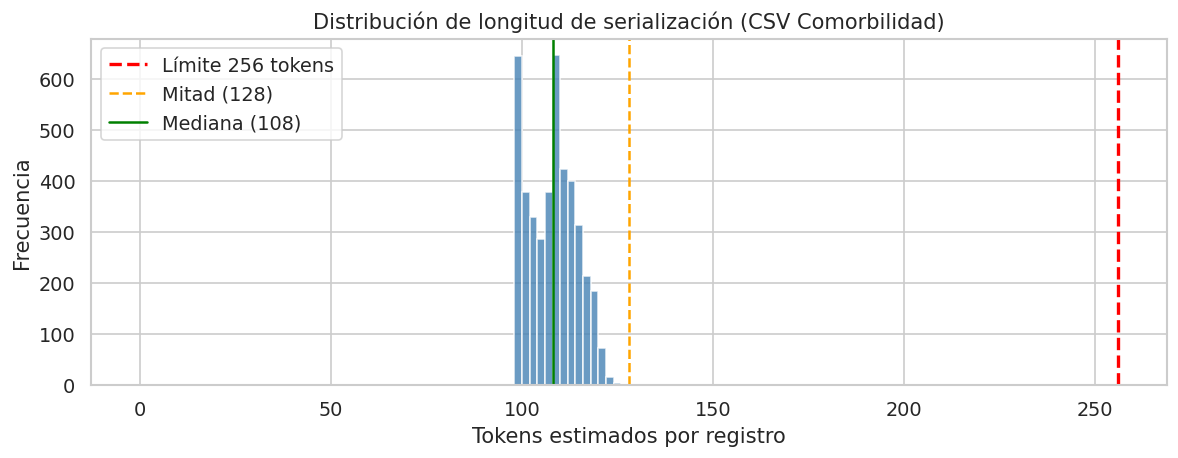

In [ ]:
# ──  Estimación de tokens por registro serializado  ──
# Heurística: cada "palabra" (split por espacio) ≈ 1 token.
# Tokens especiales ([BLK_ID], [COL], [VAL], [VAL_NULL], <UID>, </UID>, <DATE>, </DATE>)
# cuentan como 1 token cada uno.
bloques_real = {}
for blk, cols in bloques.items():
    cols_exist = [c for c in cols if c in df.columns]
    if cols_exist:
        bloques_real[blk] = cols_exist

def estimar_tokens_registro(row):
    total = 0
    for blk, cols in bloques_real.items():
        vals_bloque = {c: row[c] for c in cols}
        if not any(pd.notna(v) for v in vals_bloque.values()):
            continue
        total += 1  # [BLK_X]
        for col_name, val in vals_bloque.items():
            total += 1  # [COL]
            total += len(str(col_name).split())
            if pd.isna(val):
                total += 1  # [VAL_NULL]
            else:
                total += 1  # [VAL]
                val_str = str(val)
                if col_name == 'expediente':
                    total += 2  # <UID> </UID>
                if 'fecha' in col_name:
                    total += 2  # <DATE> </DATE>
                    val_str = str(val)[:10]
                total += len(val_str.split())
    return total

token_counts = df.apply(estimar_tokens_registro, axis=1)

# Tabla de estadísticas
exceden_128 = int((token_counts > 128).sum())
exceden_256 = int((token_counts > 256).sum())

df_token_stats = pd.DataFrame([
    {'Métrica': 'Mínimo', 'Tokens': int(token_counts.min())},
    {'Métrica': 'Mediana', 'Tokens': int(token_counts.median())},
    {'Métrica': 'Media', 'Tokens': f'{token_counts.mean():.1f}'},
    {'Métrica': 'P90', 'Tokens': int(token_counts.quantile(0.9))},
    {'Métrica': 'P95', 'Tokens': int(token_counts.quantile(0.95))},
    {'Métrica': 'P99', 'Tokens': int(token_counts.quantile(0.99))},
    {'Métrica': 'Máximo', 'Tokens': int(token_counts.max())},
    {'Métrica': 'Exceden 128', 'Tokens': f'{exceden_128} ({exceden_128/len(df)*100:.1f}%)'},
    {'Métrica': 'Exceden 256', 'Tokens': f'{exceden_256} ({exceden_256/len(df)*100:.1f}%)'},
])
display(df_token_stats.style.set_caption('Estimación de tokens por registro serializado')
        .set_table_styles([{'selector': 'caption', 'props': 'font-size:1.2em; font-weight:bold'}])
        .hide(axis='index'))

# Histograma
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(token_counts, bins=range(0, int(token_counts.max()) + 5, 2),
        color='steelblue', edgecolor='white', alpha=0.8)
ax.axvline(256, color='red', linestyle='--', linewidth=2, label='Límite 256 tokens')
ax.axvline(128, color='orange', linestyle='--', linewidth=1.5, label='Mitad (128)')
ax.axvline(token_counts.median(), color='green', linestyle='-', linewidth=1.5,
           label=f'Mediana ({token_counts.median():.0f})')
ax.set_xlabel('Tokens estimados por registro')
ax.set_ylabel('Frecuencia')
ax.set_title('Distribución de longitud de serialización (CSV Comorbilidad)')
ax.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'histograma_tokens_comorbilidad.png', dpi=150)
plt.show()
plt.show()

## 4. Resumen — Hallazgos clave y próximos pasos

#### 4.1  Diccionario de Datos — CSV Comorbilidad

In [8]:
# Cada columna se describe con 3 capas:
#   [Definición]    → qué representa semánticamente
#   [Auditoría]     → hallazgos cuantitativos del EDA
#   [Consolidación] → decisión de integración con las otras bases

diccionario_comorb = [
    {
        "Columna": "expediente",
        "Bloque": "[BLK_ADMIN]",
        "Tipo_Original": "int64",
        "Tipo_Final": "int64",
        "Tipo_Variable": "Numérica",
        "Descripcion": (
            "[Definición] Número de expediente del paciente en el INER. Clave principal de vinculación entre bases de datos. "
            "[Auditoría] Todos numéricos enteros. 0 nulos. "
            "14 expedientes con más de un nombre distinto (posibles duplicados por errores de captura). "
            "[Consolidación] Cruzar con 'EXP' en Económico y 'EXPEDIENTE' en TrabajoSocial para confirmar duplicados."
        ),
    },
    {
        "Columna": "nombre",
        "Bloque": "[BLK_ID]",
        "Tipo_Original": "str",
        "Tipo_Final": "str",
        "Tipo_Variable": "Texto libre",
        "Descripcion": (
            "[Definición] Nombre completo del paciente con formato NOMBRE(S) APELLIDO_P APELLIDO_M (multi-espacio). "
            "[Auditoría] 0 nulos. 223 registros con '?' (= Ñ mal codificada) y demás carecteres problemáticos. "
            "Multi-espacios internos en 2046 registros. "
            "[Consolidación] Normalizar caracteres problemáticos y unificar formato para comparar en Económico en Trabajo Social."
        ),
    },
    {
        "Columna": "fechaing",
        "Bloque": "[BLK_ADMIN]",
        "Tipo_Original": "str",
        "Tipo_Final": "datetime64[ns]",
        "Tipo_Variable": "Temporal",
        "Descripcion": (
            "[Definición] Fecha de ingreso del paciente al INER. "
            "[Auditoría] 0 nulos. Rango 2020-02-28 a 2023-12-19. 0 registros con egreso anterior a ingreso. 4728 registros tienen esta fecha, 19 registros presentan la misma fecha de ingreso y egreso (posible ingreso y alta el mismo día)."
            "[Consolidación] Equivalente a 'FECHA_INGRESO_INER' en Económico."
        ),
    },
    {
        "Columna": "fechaegr",
        "Bloque": "[BLK_ADMIN]",
        "Tipo_Original": "datetime64[ns]",
        "Tipo_Final": "datetime",
        "Tipo_Variable": "Fecha",
        "Descripcion": (
            "[Definición] Fecha de egreso del paciente al INER. "
            "[Auditoría] 0 nulos. Rango 2020-03-02 a 2023-12-24. 0 registros con egreso anterior a ingreso. 4728 registros tienen esta fecha, 19 registros presentan la misma fecha de ingreso y egreso (posible ingreso y alta el mismo día)."
            "[Consolidación] Equivalente a 'FECHA_DE_ALTA_MEJORIA' en Económico."
        ),
    },
    {
        "Columna": "diagnosticoprincipal",
        "Bloque": "[BLK_CLIN]",
        "Tipo_Original": "str",
        "Tipo_Final": "str",
        "Tipo_Variable": "Texto libre",
        "Descripcion": (
            "[Definición] Causa principal de ingreso al INER (COVID-19). Texto libre con alta variabilidad de captura. "
            "[Auditoría] 0 nulos. Distribución en 3 códigos CIE-10 (U07.1, U07.2, U09.9) pero con 184 variantes textuales "
            "por sinónimos, typos y falta de estandarización. "
            "[Consolidación] Mantener junto con cie101: texto aporta semántica, CIE-10 aporta estandarización."
        ),
    },
    {
        "Columna": "cie101",
        "Bloque": "[BLK_CLIN]",
        "Tipo_Original": "str",
        "Tipo_Final": "str",
        "Tipo_Variable": "Código CIE-10",
        "Descripcion": (
            "[Definición] Código CIE-10 del diagnóstico principal (Cap. XXII: U07.1, U07.2, U09.9). "
            "[Auditoría] 0 nulos. 3 valores únicos. 100% formato válido. Fuente de verdad primaria. "
            "[Consolidación] Solo en Comorbilidad."
        ),
    },
    {
        "Columna": "diagnostico2",
        "Bloque": "[BLK_CLIN]",
        "Tipo_Original": "str",
        "Tipo_Final": "str",
        "Tipo_Variable": "Texto libre",
        "Descripcion": (
            "[Definición] Complicaciones agudas derivadas de la afección principal. Texto libre. "
            "[Auditoría] 1,351 nulos (31.6%). Predominio de insuficiencia respiratoria (J96.0). "
            "Alta variabilidad textual (24+ variantes para J96.0). "
            "[Consolidación] Mantener junto con cie102 para enriquecer semántica."
        ),
    },
    {
        "Columna": "cie102",
        "Bloque": "[BLK_CLIN]",
        "Tipo_Original": "str",
        "Tipo_Final": "str",
        "Tipo_Variable": "Código CIE-10",
        "Descripcion": (
            "[Definición] Código CIE-10 del segundo diagnóstico. "
            "[Auditoría] 1,363 nulos (31.9%). 114 valores únicos. 13.4% con patrón no estándar (ej. I10.X). "
            "[Consolidación] Solo en Comorbilidad. dx2 es 100% redundante con este campo."
        ),
    },
    {
        "Columna": "diagnostico3",
        "Bloque": "[BLK_CLIN]",
        "Tipo_Original": "str",
        "Tipo_Final": "str",
        "Tipo_Variable": "Texto libre",
        "Descripcion": (
            "[Definición] Comorbilidades de base o condiciones crónicas preexistentes. Texto libre. "
            "[Auditoría] 2,715 nulos (63.5%). Mayor presencia de Diabetes (E11.9, 354 casos) y HTAS (I10.X, 432 casos). "
            "[Consolidación] Mantener junto con cie103."
        ),
    },
    {
        "Columna": "cie103",
        "Bloque": "[BLK_CLIN]",
        "Tipo_Original": "str",
        "Tipo_Final": "str",
        "Tipo_Variable": "Código CIE-10",
        "Descripcion": (
            "[Definición] Código CIE-10 del tercer diagnóstico. "
            "[Auditoría] 2,717 nulos (63.5%). 59 valores únicos. 28.5% con patrón no estándar. "
            "[Consolidación] Solo en Comorbilidad. dx3 es 100% redundante con este campo."
        ),
    },
    {
        "Columna": "diagnostico4",
        "Bloque": "[BLK_CLIN]",
        "Tipo_Original": "str",
        "Tipo_Final": "str",
        "Tipo_Variable": "Texto libre",
        "Descripcion": (
            "[Definición] Comorbilidades adicionales. Texto libre. "
            "[Auditoría] 3,817 nulos (89.2%). Destacan Diabetes Mellitus tipo II (E11.9, 207 casos) "
            "y Choque Séptico (A41.9, 86 casos). "
            "[Consolidación] Mantener junto con cie104."
        ),
    },
    {
        "Columna": "cie104",
        "Bloque": "[BLK_CLIN]",
        "Tipo_Original": "str",
        "Tipo_Final": "str",
        "Tipo_Variable": "Código CIE-10",
        "Descripcion": (
            "[Definición] Código CIE-10 del cuarto diagnóstico. "
            "[Auditoría] 3,817 nulos (89.2%). 14 valores únicos. 5.2% con patrón no estándar. "
            "[Consolidación] Solo en Comorbilidad. dx4 es 100% redundante con este campo."
        ),
    },
    {
        "Columna": "dx2",
        "Bloque": "[BLK_CLIN]",
        "Tipo_Original": "str",
        "Tipo_Final": "—",
        "Tipo_Variable": "REDUNDANTE",
        "Descripcion": (
            "[Definición] Duplicado exacto de cie102 — contiene los mismos códigos CIE-10 del segundo diagnóstico. "
            "[Auditoría] 100% coincidencia con cie102. Relación 1:1 confirmada. "
            "[Consolidación] ELIMINAR en limpieza final."
        ),
    },
    {
        "Columna": "dx3",
        "Bloque": "[BLK_CLIN]",
        "Tipo_Original": "str",
        "Tipo_Final": "—",
        "Tipo_Variable": "REDUNDANTE",
        "Descripcion": (
            "[Definición] Duplicado exacto de cie103. "
            "[Auditoría] 100% coincidencia con cie103. Relación 1:1 confirmada. "
            "[Consolidación] ELIMINAR en limpieza final."
        ),
    },
    {
        "Columna": "dx4",
        "Bloque": "[BLK_CLIN]",
        "Tipo_Original": "str",
        "Tipo_Final": "—",
        "Tipo_Variable": "REDUNDANTE",
        "Descripcion": (
            "[Definición] Duplicado exacto de cie104. "
            "[Auditoría] 100% coincidencia con cie104. Relación 1:1 confirmada. "
            "[Consolidación] ELIMINAR en limpieza final."
        ),
    },
    {
        "Columna": "obesidad",
        "Bloque": "[BLK_CLIN]",
        "Tipo_Original": "float64",
        "Tipo_Final": "int",
        "Tipo_Variable": "Flag binario",
        "Descripcion": (
            "[Definición] Indicador de obesidad como comorbilidad (0/1). "
            "[Auditoría] Binario confirmado. 0 nulos. 679 positivos (15.9%). "
            "[Consolidación] Solo en Comorbilidad. Conservar junto con obesidad1: aporta señal complementaria."
        ),
    },
    {
        "Columna": "obesidad1",
        "Bloque": "[BLK_CLIN]",
        "Tipo_Original": "float64",
        "Tipo_Final": "int",
        "Tipo_Variable": "Flag binario",
        "Descripcion": (
            "[Definición] Segundo indicador de obesidad — posiblemente un grado o subtipo específico (0/1). "
            "[Auditoría] Binario confirmado. 0 nulos. 94 positivos (2.2%). "
            "Difiere de 'obesidad' en 585 registros (86.3% coincidencia) — NO es redundante. "
            "[Consolidación] Solo en Comorbilidad. Conservar — aporta información diferenciada."
        ),
    },
    {
        "Columna": "cardiopatia",
        "Bloque": "[BLK_CLIN]",
        "Tipo_Original": "float64",
        "Tipo_Final": "int",
        "Tipo_Variable": "Flag binario",
        "Descripcion": (
            "[Definición] Indicador de cardiopatía como comorbilidad (0/1). "
            "[Auditoría] Binario confirmado. 0 nulos. 856 positivos (20.0%). "
            "[Consolidación] Solo en Comorbilidad."
        ),
    },
    {
        "Columna": "comorbi",
        "Bloque": "[BLK_CLIN]",
        "Tipo_Original": "str",
        "Tipo_Final": "category",
        "Tipo_Variable": "Categórica nominal",
        "Descripcion": (
            "[Definición] Clasificación general de comorbilidad del paciente. "
            "10 categorías: Ninguna (1,363), Otras (1,214), Obesidad/Trastornos alimentación (675), "
            "Diabetes Mellitus (605), HTAS (327), Enf. sistema renal (42), TEP &/| HAP (26), "
            "Cardiopatía Isquémica (15), EAP & ERGE (9), Insuficiencia Cardíaca (2). "
            "[Auditoría] 0 nulos. Evaluar trailing spaces. "
            "[Consolidación] Solo en Comorbilidad. Resumen de los flags binarios + diagnósticos."
        ),
    },
    {
        "Columna": "diabetes",
        "Bloque": "[BLK_CLIN]",
        "Tipo_Original": "float64",
        "Tipo_Final": "int",
        "Tipo_Variable": "Flag binario",
        "Descripcion": (
            "[Definición] Indicador de diabetes como comorbilidad (0/1). "
            "[Auditoría] Binario confirmado. 0 nulos. 739 positivos (17.3%). "
            "[Consolidación] Solo en Comorbilidad."
        ),
    },
    {
        "Columna": "nefropatia",
        "Bloque": "[BLK_CLIN]",
        "Tipo_Original": "float64",
        "Tipo_Final": "int",
        "Tipo_Variable": "Flag binario",
        "Descripcion": (
            "[Definición] Indicador de nefropatía como comorbilidad (0/1). "
            "[Auditoría] Binario confirmado. 0 nulos. 42 positivos (1.0%). "
            "[Consolidación] Solo en Comorbilidad."
        ),
    },
    {
        "Columna": "eaperge",
        "Bloque": "[BLK_CLIN]",
        "Tipo_Original": "float64",
        "Tipo_Final": "int",
        "Tipo_Variable": "Flag binario",
        "Descripcion": (
            "[Definición] Indicador de Enfermedad Ácido-Péptica (EAP) o Enfermedad por Reflujo "
            "Gastroesofágico (ERGE) como comorbilidad (0/1). "
            "[Auditoría] Binario confirmado. 0 nulos. 9 positivos (0.2%). "
            "[Consolidación] Solo en Comorbilidad."
        ),
    },
    {
        "Columna": "tephap",
        "Bloque": "[BLK_CLIN]",
        "Tipo_Original": "float64",
        "Tipo_Final": "int",
        "Tipo_Variable": "Flag binario",
        "Descripcion": (
            "[Definición] Indicador de Tromboembolismo Pulmonar (TEP) o Hipertensión Arterial "
            "Pulmonar (HAP) como comorbilidad (0/1). "
            "[Auditoría] Binario confirmado. 0 nulos. 28 positivos (0.7%). "
            "[Consolidación] Solo en Comorbilidad."
        ),
    },
    {
        "Columna": "comorbicv",
        "Bloque": "[BLK_CLIN]",
        "Tipo_Original": "str",
        "Tipo_Final": "category",
        "Tipo_Variable": "Categórica nominal",
        "Descripcion": (
            "[Definición] Clasificación de comorbilidad cardiovascular específica del paciente. "
            "5 categorías: 0/Sin CV (3,432), HTAS (789), TEP &/| HAP (28), "
            "Cardiopatía Isquémica (26), Insuficiencia Cardíaca (3). "
            "[Auditoría] 0 nulos reales (dtype str). El valor '0' indica ausencia de comorbilidad CV. "
            "NO es numérica — fue erróneamente tratada como tal; es categórica. "
            "[Consolidación] Solo en Comorbilidad. Complementa a comorbi (general) con detalle CV."
        ),
    },
]

df_dic = pd.DataFrame(diccionario_comorb)
display(df_dic.style.set_caption("4.1 — Diccionario de Datos: CSV Comorbilidad (24 columnas)")
        .set_table_styles([
            {'selector': 'caption', 'props': 'font-size:1.2em; font-weight:bold'},
            {'selector': 'td', 'props': 'text-align:left; max-width:500px; white-space:pre-wrap'},
        ])
        .set_properties(subset=['Descripcion'], **{'font-size': '0.85em', 'max-width': '600px'})
        .hide(axis='index'))

print(f"\n✓ Diccionario: {len(df_dic)} columnas documentadas")
print(f"  Bloques: {df_dic['Bloque'].value_counts().to_dict()}")
n_redund = df_dic[df_dic['Tipo_Variable'] == 'REDUNDANTE'].shape[0]
print(f"  Redundantes a eliminar: {n_redund} (dx2, dx3, dx4)")

Columna,Bloque,Tipo_Original,Tipo_Final,Tipo_Variable,Descripcion
expediente,[BLK_ADMIN],int64,int64,Numérica,[Definición] Número de expediente del paciente en el INER. Clave principal de vinculación entre bases de datos. [Auditoría] Todos numéricos enteros. 0 nulos. 14 expedientes con más de un nombre distinto (posibles duplicados por errores de captura). [Consolidación] Cruzar con 'EXP' en Económico y 'EXPEDIENTE' en TrabajoSocial para confirmar duplicados.
nombre,[BLK_ID],str,str,Texto libre,[Definición] Nombre completo del paciente con formato NOMBRE(S) APELLIDO_P APELLIDO_M (multi-espacio). [Auditoría] 0 nulos. 223 registros con '?' (= Ñ mal codificada) y demás carecteres problemáticos. Multi-espacios internos en 2046 registros. [Consolidación] Normalizar caracteres problemáticos y unificar formato para comparar en Económico en Trabajo Social.
fechaing,[BLK_ADMIN],str,datetime64[ns],Temporal,"[Definición] Fecha de ingreso del paciente al INER. [Auditoría] 0 nulos. Rango 2020-02-28 a 2023-12-19. 0 registros con egreso anterior a ingreso. 4728 registros tienen esta fecha, 19 registros presentan la misma fecha de ingreso y egreso (posible ingreso y alta el mismo día).[Consolidación] Equivalente a 'FECHA_INGRESO_INER' en Económico."
fechaegr,[BLK_ADMIN],datetime64[ns],datetime,Fecha,"[Definición] Fecha de egreso del paciente al INER. [Auditoría] 0 nulos. Rango 2020-03-02 a 2023-12-24. 0 registros con egreso anterior a ingreso. 4728 registros tienen esta fecha, 19 registros presentan la misma fecha de ingreso y egreso (posible ingreso y alta el mismo día).[Consolidación] Equivalente a 'FECHA_DE_ALTA_MEJORIA' en Económico."
diagnosticoprincipal,[BLK_CLIN],str,str,Texto libre,"[Definición] Causa principal de ingreso al INER (COVID-19). Texto libre con alta variabilidad de captura. [Auditoría] 0 nulos. Distribución en 3 códigos CIE-10 (U07.1, U07.2, U09.9) pero con 184 variantes textuales por sinónimos, typos y falta de estandarización. [Consolidación] Mantener junto con cie101: texto aporta semántica, CIE-10 aporta estandarización."
cie101,[BLK_CLIN],str,str,Código CIE-10,"[Definición] Código CIE-10 del diagnóstico principal (Cap. XXII: U07.1, U07.2, U09.9). [Auditoría] 0 nulos. 3 valores únicos. 100% formato válido. Fuente de verdad primaria. [Consolidación] Solo en Comorbilidad."
diagnostico2,[BLK_CLIN],str,str,Texto libre,"[Definición] Complicaciones agudas derivadas de la afección principal. Texto libre. [Auditoría] 1,351 nulos (31.6%). Predominio de insuficiencia respiratoria (J96.0). Alta variabilidad textual (24+ variantes para J96.0). [Consolidación] Mantener junto con cie102 para enriquecer semántica."
cie102,[BLK_CLIN],str,str,Código CIE-10,"[Definición] Código CIE-10 del segundo diagnóstico. [Auditoría] 1,363 nulos (31.9%). 114 valores únicos. 13.4% con patrón no estándar (ej. I10.X). [Consolidación] Solo en Comorbilidad. dx2 es 100% redundante con este campo."
diagnostico3,[BLK_CLIN],str,str,Texto libre,"[Definición] Comorbilidades de base o condiciones crónicas preexistentes. Texto libre. [Auditoría] 2,715 nulos (63.5%). Mayor presencia de Diabetes (E11.9, 354 casos) y HTAS (I10.X, 432 casos). [Consolidación] Mantener junto con cie103."
cie103,[BLK_CLIN],str,str,Código CIE-10,"[Definición] Código CIE-10 del tercer diagnóstico. [Auditoría] 2,717 nulos (63.5%). 59 valores únicos. 28.5% con patrón no estándar. [Consolidación] Solo en Comorbilidad. dx3 es 100% redundante con este campo."



✓ Diccionario: 24 columnas documentadas
  Bloques: {'[BLK_CLIN]': 20, '[BLK_ADMIN]': 3, '[BLK_ID]': 1}
  Redundantes a eliminar: 3 (dx2, dx3, dx4)


### 1.4 Resumen de hallazgos de la caracterización de las columnas

**Tipos de variable confirmados tras el desglose:**

| Tipo | Columnas | Nota |
|------|----------|------|
| **Numérica (`int64`)** | `expediente` | Identificador numérico, todos son enteros — es clave de cruce entre bases |
| **Texto libre (`str`)** | `nombre` | Formato `NOMBRE(S) AP_P AP_M` con multi-espacios  |
| **Texto libre (`str`)** | `diagnosticoprincipal`, `diagnostico2`, `diagnostico3`, `diagnostico4` | Descripciones con alta variabilidad de captura manual |
| **Códigos CIE-10 (`str`)** | `cie101`, `cie102`, `cie103`, `cie104` | Estructura alfanumérica compatible con CIE-10; validación formal de patrón en Sec 2.5 |
| **Códigos dx (`str`)** | `dx2`, `dx3`, `dx4` | Alta similitud observada respecto a cie102-cie104; confirmar coincidencia exacta en Sec 2.6 |
| **Categórica nominal (`str`)** | `comorbi` | **comorbilidad general** 10 categorías: Ninguna, Otras, Obesidad, Diabetes, HTAS, etc. |
| **Categórica nominal (`str`)** | `comorbicv` | **comorbilidad cardiovascular** 5 valores: 0 (sin CV), HTAS, TEP &/\| HAP, Cardiopatía Isquémica, Insuficiencia Cardíaca |
| **Variables binarias (`float64`)** | `obesidad`, `obesidad1`, `cardiopatia`, `diabetes`, `nefropatia`, `eaperge`, `tephap` | **7 columnas binarias:**, todas vienen con formato numérico  deben ser convertidas a booleano. Las cols  `obesidad` y `obesidad1` muestran discrepancias y no deben asumirse equivalentes|
| **Fecha (`str`)** | `fechaing`, `fechaegr` | Venía con formato de cadena de texto fue convertido a `datetime64[ns]`. Rango 2020-2023 correcto |

### 4.2 Calidad — Resumen

| Campo | Hallazgo | Impacto RL |
|-------|----------|------------|
| **nombre** | 223 caracteres `?` = Ñ mal codificada; multi-espacios en ~48%; formato `NOMBRE AP_P AP_M` diferente a Económico | Mapear `?` → `Ñ`, colapsar multi-espacios, normalizar formato cross-database |
| **dx2/dx3/dx4** | **100% redundantes** con cie102/cie103/cie104 — duplicados exactos | **Eliminar** en limpieza final para ahorrar ~10–15 tokens |
| **obesidad vs obesidad1** | Difieren en 585 registros (86.3% coincidencia). `obesidad`: 679 positivos, `obesidad1`: 94 positivos | **NO son redundantes** — ambos se conservan como señal complementaria |
| **comorbicv** | **Categórica** (no numérica) — 5 categorías de riesgo cardio vascular; valor `0` = sin comorbilidad CV | Tratar como categórica nominal en serialización |
| **diagnosticoprincipal/2/3/4** | Alta variabilidad textual por captura manual (ej. 184 variantes para U07.1) | CIE-10 como fuente de verdad primaria; texto complementa semántica |
| **comorbi** | 10 categorías — resumen general de comorbilidad | Normalizar con `strip()` + `upper()` |

### 4.3 Bloques Semánticos — Completitud

| Bloque | Columnas | Nota |
|--------|----------|------|
| `[BLK_ID]` | 1 (nombre) | Solo 1 campo — formato cross-database diferente |
| `[BLK_CLIN]` | 20 → **17 útiles** (tras eliminar dx2/dx3/dx4) | Bloque dominante: diagnósticos + CIE-10, comorbilidades (`comorbi`, `comorbicv`) y flags binarios |
| `[BLK_GEO]` | — | No aplica en este CSV |
| `[BLK_SOCIO]` | — | No aplica en este CSV |
| `[BLK_ADMIN]` | 3 (`expediente`, `fechaing`, `fechaegr`) | 100% completo |

### 4.4 Presupuesto de Tokens

- **Mediana: ~108 tokens** por registro serializado (24 columnas originales)
- **Máximo: ~128 tokens** — dentro del límite de **256 tokens**
- **Exceden 128:** 0 registros | **Exceden 256:** 0 registros
- Tras eliminar 3 columnas redundantes (`dx2`/`dx3`/`dx4`): ahorro de ~10–15 tokens
- **No se requiere** TF-IDF summarization para este CSV

### 4.5 Acciones Pre-Serialización (priorizadas)

1. **Eliminar columnas redundantes**: `dx2`, `dx3`, `dx4` (100% = cie102/103/104)
2. **Corregir codificación nombre**: mapear `?` → `Ñ` (223 registros); colapsar multi-espacios; normalizar formato cross-database
3. **Reclasificar `comorbicv`**: tratar como categórica nominal, no numérica; renombrar `0` → `Sin comorbilidad CV`
4. **Consolidar diagnóstico + CIE-10**: combinar texto libre (semántica) con código estandarizado por nivel (1–4)
5. **Normalizar categóricas**: `strip()` + `upper()` en `diagnosticoprincipal`, `comorbi`, `comorbicv`
6. **Renombrar columnas**: `diagnosticoprincipal` → `diagnostico_1`, `diagnostico[2-4]` → `diagnostico_[2-4]`, `cie10[1-4]` → `cie10_[1-4]`
7. **Documentar semántica de `obesidad1`**: confirmar si representa grado/subtipo y mantener ambos flags
8. **Resolver conflictos expediente-nombre**: 14 expedientes con >1 nombre distinto